# Model Result Comparisons

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl

In [2]:
NUM_COL = 'true_prc'
DATE_COL = 'dlycaldt'
TICKER_COL1 = 'permno'
TICKER_COL2 = 'ticker'
SPLIT_DATE = pd.to_datetime("2021-01-01")
START_BALANCE = 1000
snp_ticker = "snp500"

model_dict = {
    "random_walk": "./data/random_walk_test_returns_072426_01.csv",
    "pure_vg_win3": "./data/all_avsp_simple_test_rets_window_3.csv",
    "xgb_reg": "./data/xgboost_reg_tuned_model_returns_072026_01.csv",
    "tf_reg": "./data/tf_tuned_reg_model_returns_072826_01.csv",
    "xgb_class": "./data/xgboost_class_tuned_model_returns_072126_01.csv",
    "tf_class": "./data/tf_tuned_class_model_returns_072926_01.csv",
    "S&P 500": "./data/s&p500_returns.csv"
}

# model_dict = {
#     "xgb_reg": "./data/xgboost_reg_tuned_model_returns_072026_01.csv",
#     "tf_reg": "./data/tf_tuned_reg_model_returns_072826_01.csv",
#     "xgb_class": "./data/xgboost_class_tuned_model_returns_072126_01.csv",
#     "tf_class": "./data/tf_tuned_class_model_returns_072926_01.csv"
# }

In [13]:
dfs = []

for model_name, filename in model_dict.items():
    df = pd.read_csv(filename)
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df["model"] = model_name
    dfs.append(df)

ret_df = pd.concat(dfs, ignore_index=True)
ret_df = ret_df[ret_df[DATE_COL] >= SPLIT_DATE].reset_index(drop=True)

survival_tickers = ret_df[ret_df[DATE_COL] == pd.Timestamp('2025-12-31')][[TICKER_COL1, TICKER_COL2]].drop_duplicates()
ret_df = ret_df.merge(survival_tickers, on=[TICKER_COL1, TICKER_COL2], how='inner').reset_index(drop=True)

In [15]:
snp_start = ret_df[ret_df[TICKER_COL1] == snp_ticker].sort_values(DATE_COL)['strat_ret'].values[0]

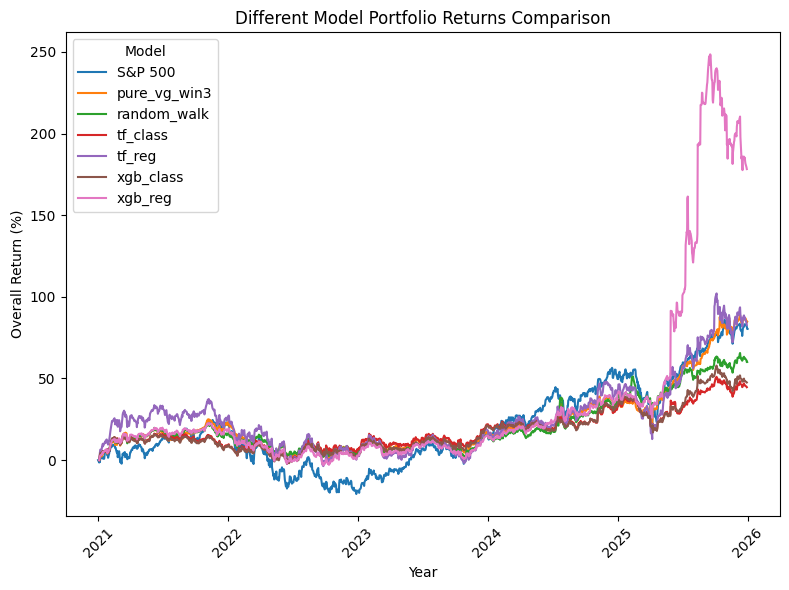

In [29]:
plot_df = (ret_df.groupby(["model", DATE_COL]).agg(strat_ret=("strat_ret", "sum"))
           .reset_index().sort_values(["model", DATE_COL]))

first_seen = ret_df.groupby(["model", TICKER_COL1])[DATE_COL].min().reset_index()
new_counts = first_seen.groupby(["model", DATE_COL]).size().rename("new_stocks").reset_index()

plot_df = plot_df.merge(new_counts, on=["model", DATE_COL], how="left")
plot_df["num_stocks"] = plot_df["new_stocks"].fillna(0).groupby(plot_df["model"]).cumsum()

plot_df["base_bal"] = plot_df["num_stocks"] * START_BALANCE
plot_df.loc[plot_df["model"] == "S&P 500", "base_bal"] = snp_start

plot_df["strat_pct_growth"] = (plot_df["strat_ret"] / plot_df["base_bal"] - 1) * 100
snp_end = plot_df.loc[plot_df["model"] == "S&P 500", "strat_pct_growth"].iloc[-1]

plot_df.rename(columns={"model": "Model"}, inplace=True)

plt.figure(figsize=(8, 6))
sns.lineplot(data=plot_df, x=DATE_COL, y="strat_pct_growth", hue="Model")

plt.title("Different Model Portfolio Returns Comparison")
plt.ylabel("Overall Return (%)")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

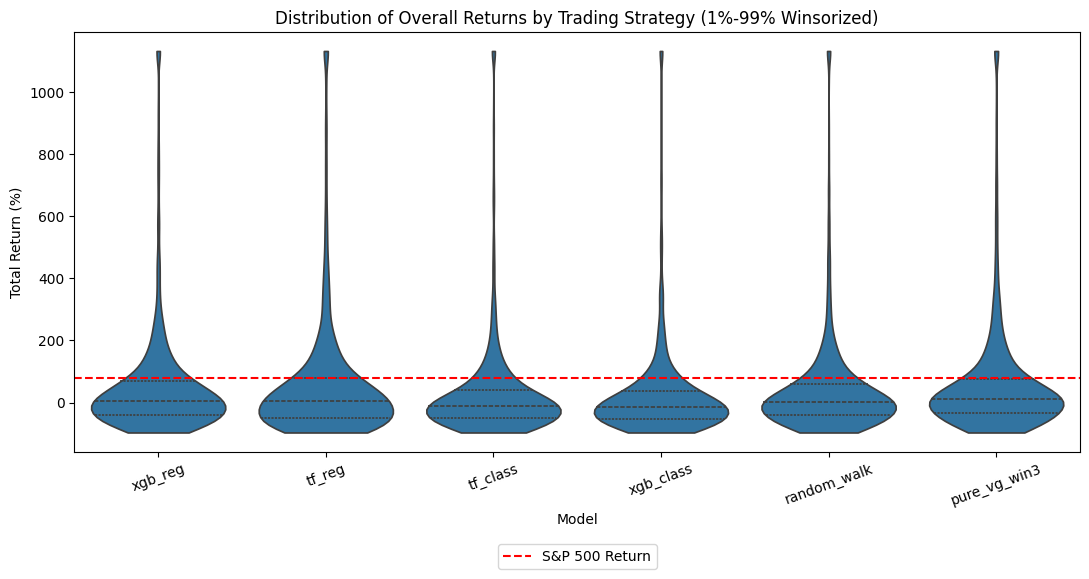

In [17]:
plot_df = ret_df.copy()

plot_df = (plot_df.sort_values(DATE_COL)
    .groupby(["model", TICKER_COL1, TICKER_COL2])
    .tail(1).copy())

plot_df["strat_pct_return"] = (plot_df["strat_ret"] / START_BALANCE - 1) * 100

plot_df = plot_df[plot_df['model'] != "S&P 500"].reset_index(drop=True)

### Cap extreme returns at 1st/99th percentile
low, high = plot_df["strat_pct_return"].quantile([0.01, 0.99])

plot_df["strat_pct_return_plot"] = plot_df["strat_pct_return"].clip(low, high)

plt.figure(figsize=(11, 6))

sns.violinplot(data=plot_df, x="model", y="strat_pct_return_plot", 
               inner="quartile", cut=0, density_norm="width")

plt.axhline(y=snp_end, label='S&P 500 Return', linestyle='--', color='red')
plt.title("Distribution of Overall Returns by Trading Strategy (1%-99% Winsorized)")
plt.xlabel("Model")
plt.ylabel("Total Return (%)")
plt.xticks(rotation=20)
plt.legend(loc="center", bbox_to_anchor=(0.5, -0.25))
plt.tight_layout()
plt.show();

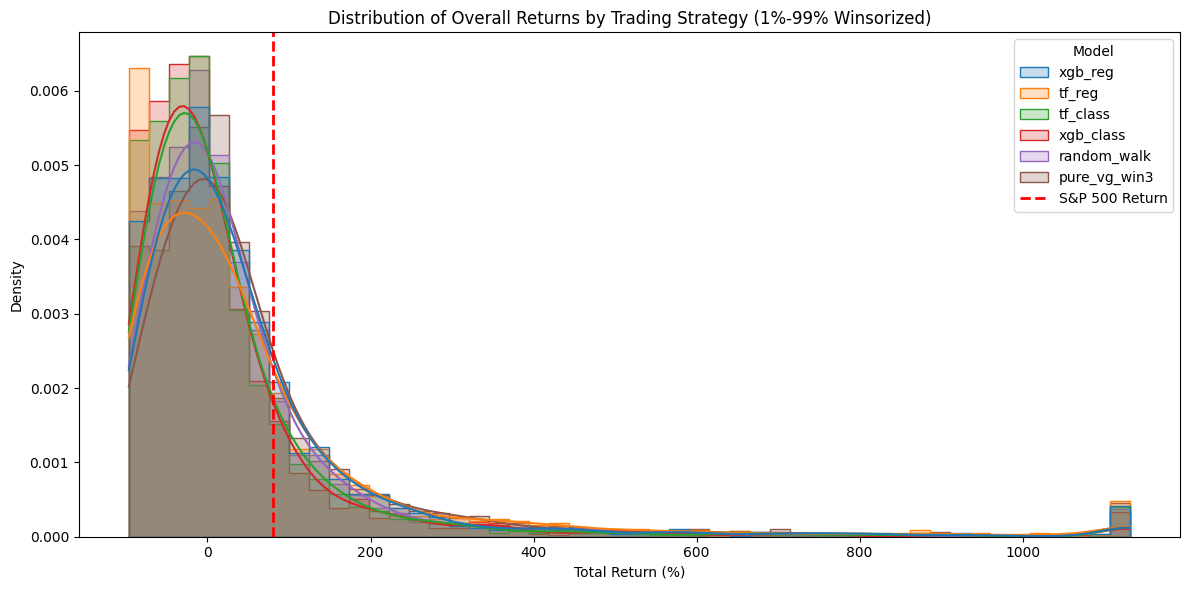

In [18]:
### Cut off extreme returns for plotting
low, high = plot_df["strat_pct_return"].quantile([0.01, 0.99])
plot_df["strat_pct_return_plot"] = plot_df["strat_pct_return"].clip(low, high)

plt.figure(figsize=(12, 6))

ax = sns.histplot(data=plot_df, x="strat_pct_return_plot", hue="model",
                  bins=50, stat="density", common_norm=False, element="step", kde=True)

line = ax.axvline(x=snp_end, color="red", linestyle="--",
    linewidth=2, label="S&P 500 Return")

leg = ax.get_legend()
handles = leg.legend_handles
labels = [t.get_text() for t in leg.get_texts()]

handles.append(line)
labels.append("S&P 500 Return")

leg.remove()

ax.legend(
    handles,
    labels,
    title="Model",
    loc="upper right",
    bbox_to_anchor=(1, 1),
    frameon=True
)

plt.title("Distribution of Overall Returns by Trading Strategy (1%-99% Winsorized)")
plt.xlabel("Total Return (%)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [24]:
summary_df = ret_df.groupby(["model", DATE_COL]).agg(strat_ret=("strat_ret", "sum")).reset_index().sort_values(["model", DATE_COL])

first_seen = ret_df.groupby(["model", TICKER_COL1])[DATE_COL].min().reset_index()
new_counts = first_seen.groupby(["model", DATE_COL]).size().rename("new_stocks").reset_index()

summary_df = summary_df.merge(new_counts, on=["model", DATE_COL], how="left")
summary_df["num_stocks"] = summary_df["new_stocks"].fillna(0).groupby(summary_df["model"]).cumsum()

summary_df["base_bal"] = summary_df["num_stocks"] * START_BALANCE
summary_df["strat_pct_growth"] = (summary_df["strat_ret"] / summary_df["base_bal"] - 1) * 100

summary_df.loc[summary_df["model"] == "S&P 500", "strat_pct_growth"] = snp_end

summary_df = (summary_df.sort_values(["model", DATE_COL]).groupby("model", as_index=True)
              .agg({"strat_pct_growth": "last"}).rename(columns={"strat_pct_growth": "Total Portfolio Growth"}))

summary_df["Total Portfolio Growth"] = summary_df["Total Portfolio Growth"].round(2)

In [25]:
summary_df

,Total Portfolio Growth
model,
S&P 500,80.33
pure_vg_win3,84.75
random_walk,60.10
tf_class,44.67
tf_reg,82.75
xgb_class,47.57
xgb_reg,178.27


In [26]:
sub_df = ret_df.copy()

sub_df = (sub_df.sort_values(DATE_COL)
    .groupby(["model", TICKER_COL1, TICKER_COL2])
    .tail(1).copy())

sub_df["strat_pct_return"] = (sub_df["strat_ret"] / START_BALANCE - 1) * 100
sub_df = sub_df.groupby("model").agg(median_return=("strat_pct_return", "median"), q25_return=("strat_pct_return", lambda x: round(np.quantile(x, 0.25), 2)),
                            q75_return=("strat_pct_return", lambda x: round(np.quantile(x, 0.75), 2)), std_return=("strat_pct_return", "std"))
sub_df['std_return'] = sub_df['std_return'].round(2)
sub_df['median_return'] = sub_df['median_return'].round(2)
sub_df.loc["S&P 500", :] = [round(snp_end, 2), round(snp_end, 2), round(snp_end, 2), 0.0]

In [27]:
sub_df

,median_return,q25_return,q75_return,std_return
model,,,,
S&P 500,80.33,80.33,80.33,0.00
pure_vg_win3,12.06,-34.53,74.79,557.23
random_walk,0.24,-41.45,58.12,457.02
tf_class,-11.14,-50.32,41.30,339.18
tf_reg,4.44,-50.90,77.50,612.65
xgb_class,-13.15,-51.67,37.70,618.34
xgb_reg,4.96,-40.90,68.50,5655.92
